Data Understand and EDA
- Rohan

Tab used eventually: 23-25_data_updated

In [1]:
import pandas as pd

file_path = "C:/Users/rohan/Downloads/TOUCHABLE CHAPA Chapter 40B Application Data 2021-2023 & 10_2023-05_2025.xlsx"

sheet_names = pd.ExcelFile(file_path).sheet_names
print("Available Sheets:")
for s in sheet_names:
    print("-", s)

Available Sheets:
- 2023-2025
- Saniya 2023-2025
- Clean Saniya 2023-2025
- Copy Clean Saniya 23-25
- 23-25_data_updated
- NEW 2023-2025
- 2021-2023
- CLEAN Kayla 2021-2023
- Copy of CLEAN Kayla 2021-2023
- Geocoded Kayla 2021-2023
- Kayla Working 2021-2023
- Kayla 2021-2023 Working 2.0
- CLEAN w stats Kayla 2021-2023


In [2]:
manual_sheets = [
    "2023-2025",
    "Copy Clean Saniya 23-25",
    "23-25_data_updated",
    "NEW 2023-2025"
]

data_dict = {sheet: pd.read_excel(file_path, sheet_name=sheet) for sheet in manual_sheets}

for sheet, df in data_dict.items():
    print(f"\nData from sheet: {sheet}")
    print(df.head(2))
    print("Shape:", df.shape)


Data from sheet: 2023-2025
   ID Number             Submission Date    Application Property      Source  \
0     314921  2023-10-21 19:05:21.175000        Groton, 503 Main  MyMassHome   
1     827042  2023-10-24 20:41:07.886000  North Andover Unit 109  MyMassHome   

    Age        Race/Ethnicity Disability Current Residence  HH Size  \
0  44.0  Choose not to answer         No         Watertown        2   
1  32.0                 White         No     Haverhill, MA        1   

   Dependents        HH Type  HH Income  HH Assets FTHB Class?  
0           0  Single person    60000.0       2.00         Yes  
1           0  Single person    62608.0   26866.69         Yes  
Shape: (1360, 14)

Data from sheet: Copy Clean Saniya 23-25
   ID Number Submission Date  Submission Time   \
0        101       2024-05-28         13:31:01   
1        101       2024-07-21         17:33:34   

                    Application Property Application City/Town  \
0   14 Caspian Way, Unit 23 ~ Leominster     

In [3]:
for sheet, df in data_dict.items():
    print(f"\n----Structure check: {sheet}----")
    print(df.info())
    print("/n----Null values check: {sheet}----")
    print(df.isnull().sum())


----Structure check: 2023-2025----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1360 entries, 0 to 1359
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID Number             1360 non-null   int64  
 1   Submission Date       1360 non-null   object 
 2   Application Property  1359 non-null   object 
 3   Source                1356 non-null   object 
 4   Age                   1359 non-null   float64
 5   Race/Ethnicity        1357 non-null   object 
 6   Disability            1358 non-null   object 
 7   Current Residence     1359 non-null   object 
 8   HH Size               1360 non-null   int64  
 9   Dependents            1360 non-null   int64  
 10  HH Type               1360 non-null   object 
 11  HH Income             1355 non-null   float64
 12  HH Assets             1359 non-null   float64
 13  FTHB Class?           1357 non-null   object 
dtypes: float64(3), int64(3), object(8)
m

In [9]:
df = data_dict["23-25_data_updated"].copy()
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')


print(df.info())
print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id_number                    1359 non-null   int64         
 1   submission_date              1359 non-null   datetime64[ns]
 2   submission_time              1359 non-null   object        
 3   application_property         1359 non-null   object        
 4   application_city_town        1359 non-null   object        
 5   application_st_address       1359 non-null   object        
 6   application_unit             594 non-null    object        
 7   source_new                   1335 non-null   object        
 8   age                          1358 non-null   float64       
 9   race_combination_normalized  1359 non-null   object        
 10  census_races                 1359 non-null   object        
 11  disability                   1357 non-null 

In [10]:
df =df.drop(columns=['zip'])
fill_values = {
    'match_type': 'Unknown',
    'matched_address': 'Unknown',
    'source_new': 'Unknown',
    'disability': 'Unknown',
    'current_residence_town_city': 'Unknown',
    'current_residence_state': 'Unknown',
    'fthb_class?': 'Unknown'
}
df = df.fillna(fill_values)

df['hh_income'] = df['hh_income'].fillna(df['hh_income'].median())

print(df.isnull().sum().sort_values(ascending=False).head(10))

application_unit               765
age                              1
hh_assets                        1
id_number                        0
application_property             0
submission_time                  0
application_st_address           0
application_city_town            0
source_new                       0
race_combination_normalized      0
dtype: int64


In [11]:
print("📊 Numeric Columns Summary:\n")
print(df.describe())

print("\n🧠 Data Types Overview:")
print(df.dtypes.value_counts())

categorical_cols = df.select_dtypes(include='object').columns
print("\nCategorical Columns:\n", categorical_cols.tolist())


📊 Numeric Columns Summary:

           id_number                submission_date          age      hh_size  \
count    1359.000000                           1359  1358.000000  1359.000000   
mean   509101.779249  2024-07-25 16:04:14.304635904    41.023932     2.175865   
min       101.000000            2023-10-21 00:00:00     0.000000     0.000000   
25%    251857.000000            2024-05-09 12:00:00    31.000000     1.000000   
50%    521091.000000            2024-07-01 00:00:00    38.000000     2.000000   
75%    744130.000000            2024-11-05 12:00:00    49.000000     3.000000   
max    998583.000000            2025-05-13 00:00:00    86.000000    31.000000   
std    285626.609016                            NaN    13.610772     1.578801   

        dependents     hh_income      hh_assets    unique_id  
count  1359.000000  1.359000e+03    1358.000000  1359.000000  
mean      0.628403  1.181514e+05   43125.715390   680.000000  
min       0.000000  7.000000e+01       0.000000     1

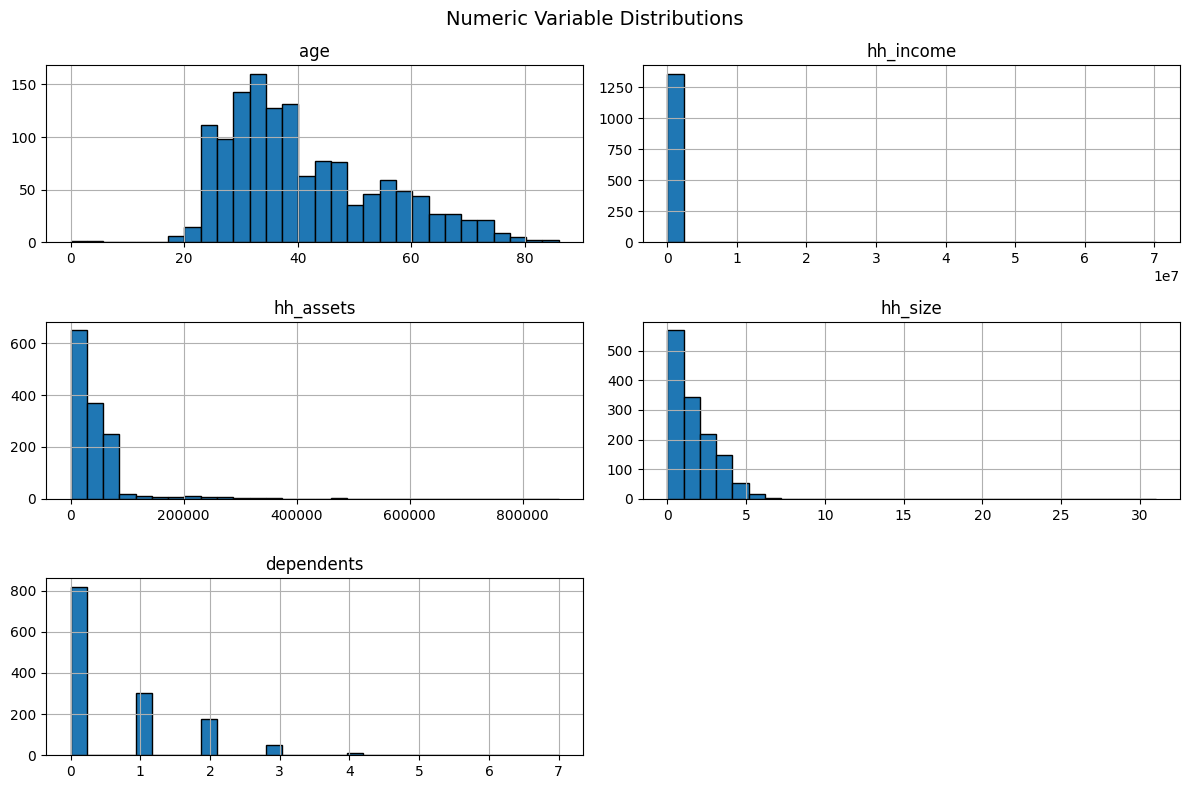

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['age', 'hh_income', 'hh_assets', 'hh_size', 'dependents']

df[numeric_cols].hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.suptitle('Numeric Variable Distributions', fontsize=14)
plt.tight_layout()
plt.show()


===== RACE_COMBINATION_NORMALIZED =====

📊 Frequency distribution:
race_combination_normalized
White                                                666
Black or African American                            187
Hispanic or Latino                                   149
Asian                                                130
Choose not to answer                                  51
Asian, Pacific Islander or Native Hawaiian            44
Middle Eastern or North African                       34
Black or African American, Hispanic or Latino         26
Hispanic or Latino, White                             23
Black or African American, White                      11
Middle Eastern or North African, White                 7
Asian, White                                           6
Native American or Alaskan Native                      4
Asian, Pacific Islander or Native Hawaiian, White      4
Missing                                                3
Name: count, dtype: int64

💵 Median Household Inc

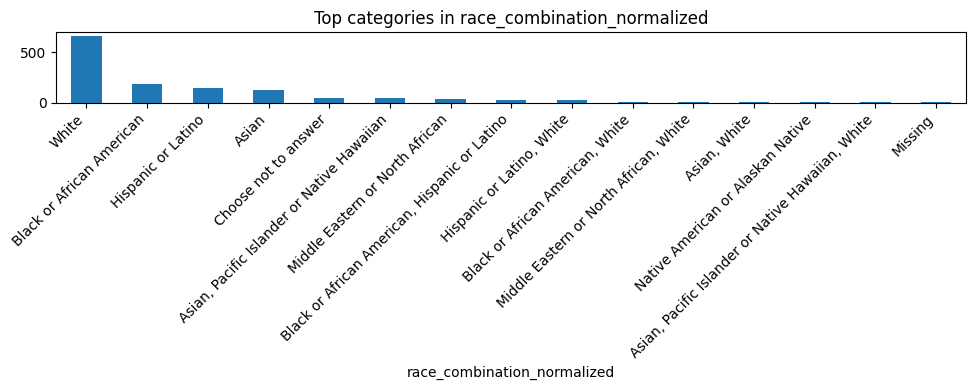


===== HH_TYPE_STANDARDIZED =====

📊 Frequency distribution:
hh_type_standardized
Single person                                      630
 Married/partners/couple, no dependents            412
Single parent                                      275
 More than one related adults, with dependents      17
Other                                               13
 More than one related adults, no dependents        10
 Married/partners/couple, with dependents            2
Name: count, dtype: int64

💵 Median Household Income by hh_type_standardized
hh_type_standardized
 More than one related adults, with dependents     75000.0
 Married/partners/couple, no dependents            72116.5
 Married/partners/couple, with dependents          70480.0
Single parent                                      66838.8
 More than one related adults, no dependents       66444.2
Single person                                      61000.0
Other                                              60000.0
Name: hh_income, dtype

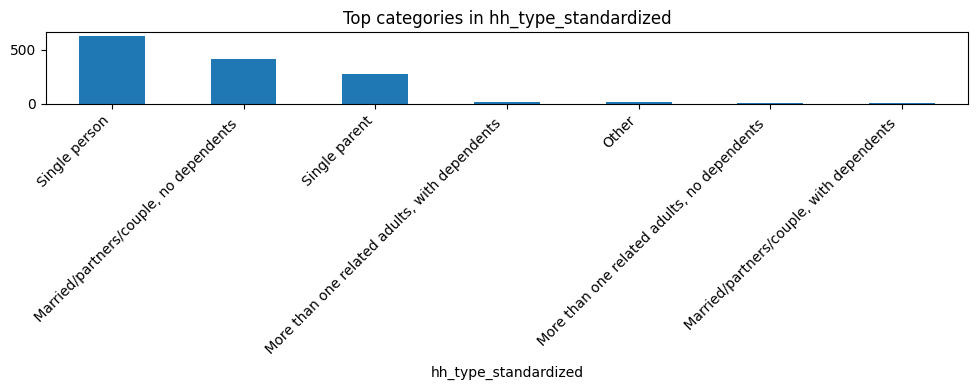


===== MSA =====

📊 Frequency distribution:
msa
Boston-Cambridge-Newton, MA-NH      640
Worcester, MA                       457
Boston-Cambridge-Newton, MA–NH      144
Providence-Warwick, RI-MA            63
Amherst Town-Northampton, MA         20
N/A: Dukes County Vineyard Haven     18
Barnstable Town, MA                  17
Name: count, dtype: int64

💵 Median Household Income by msa
msa
Providence-Warwick, RI-MA           73500.00
Boston-Cambridge-Newton, MA-NH      69454.31
Barnstable Town, MA                 67200.00
Worcester, MA                       61393.71
Boston-Cambridge-Newton, MA–NH      60000.00
N/A: Dukes County Vineyard Haven    58183.00
Amherst Town-Northampton, MA        55000.00
Name: hh_income, dtype: float64


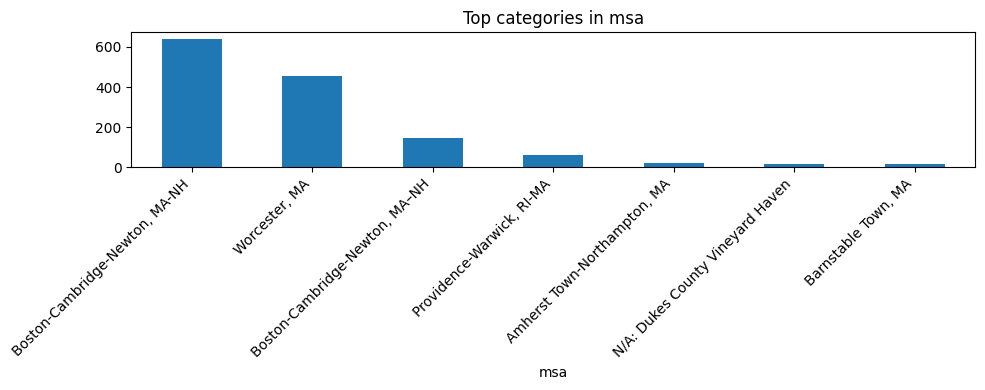


===== MATCH_STATUS =====

📊 Frequency distribution:
match_status
Match       1209
No_Match     150
Name: count, dtype: int64

💵 Median Household Income by match_status
match_status
Match       65558.0
No_Match    59950.0
Name: hh_income, dtype: float64


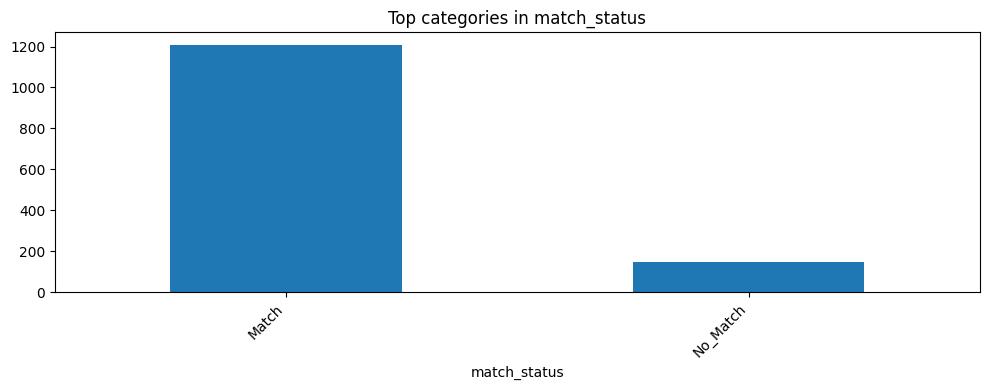


===== FTHB_CLASS? =====

📊 Frequency distribution:
fthb_class?
No         746
Yes        610
Unknown      3
Name: count, dtype: int64

💵 Median Household Income by fthb_class?
fthb_class?
Unknown    73000.0
Yes        67237.3
No         63478.5
Name: hh_income, dtype: float64


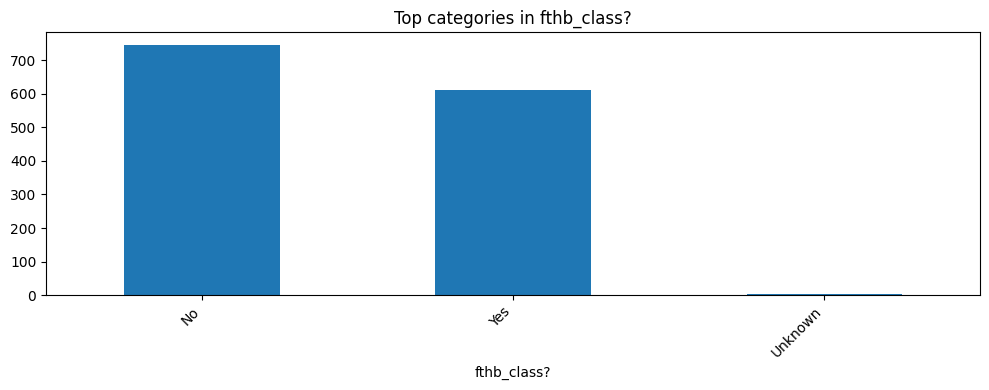

In [ ]:
categorical_cols_summary = [
    'race_combination_normalized',
    'hh_type_standardized',
    'msa',
    'match_status',
    'fthb_class?'
]

for col in categorical_cols_summary:
    print(f"\n===== {col.upper()} =====")
    
    # 📊 Frequency distribution
    counts = df[col].value_counts(dropna=False)
    print("\n📊 Frequency distribution:")
    print(counts.head(15)) 
    
    # 💵 Median Household Income by category
    if 'hh_income' in df.columns:
        income_summary = (
            df.groupby(col)['hh_income']
            .median()
            .sort_values(ascending=False)
        )
        print("\n💵 Median Household Income by", col)
        print(income_summary.head(15))
    
    # Bar plot of frequencies
    plt.figure(figsize=(10, 4))
    counts.head(15).plot(kind='bar')
    plt.title(f"Top categories in {col}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

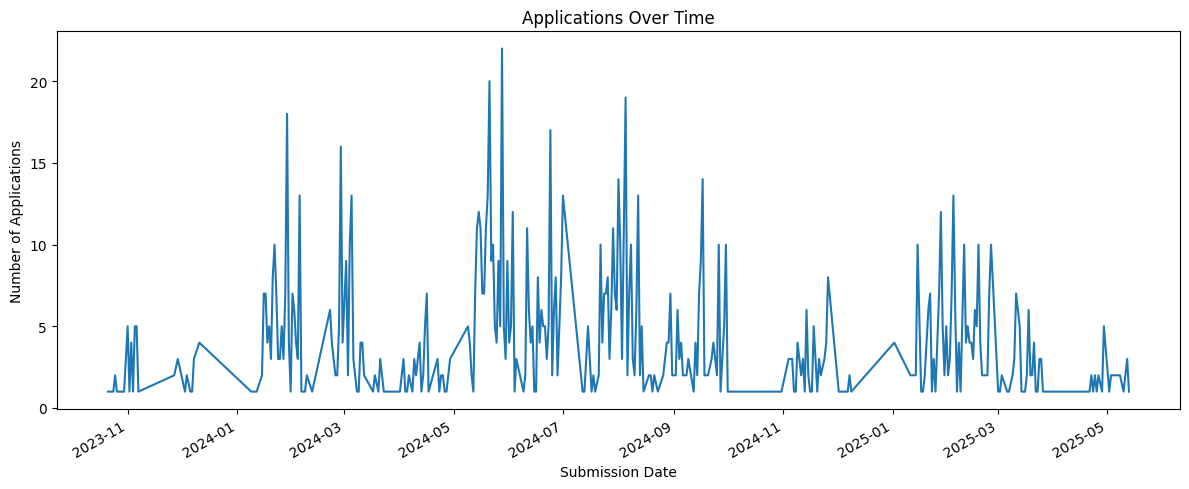

In [17]:
plt.figure(figsize=(12,5))
df['submission_date'].value_counts().sort_index().plot()
plt.title('Applications Over Time')
plt.xlabel('Submission Date')
plt.ylabel('Number of Applications')
plt.tight_layout()
plt.show()